# Reliability Study Summary Analysis

This notebook generates summary visualizations from:
- cross_split_metrics.csv (Dice, Jaccard, relative_diff per model/subject)
- image_quality_metrics.csv (SNR, CNR per subject)

Run each cell in order in your Jupyter notebook.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Load data
reliability_df = pd.read_csv("../data/cross_split_metrics.csv")
quality_df = pd.read_csv("../data/image_quality_metrics.csv")
infodump_df = pd.read_csv("../data/subject_quality_metrics.csv")


print(
    f"Reliability data: {len(reliability_df)} rows, {reliability_df['subject_id'].nunique()} subjects"
)
print(f"Quality data: {len(quality_df)} subjects")
print(f"Infodump data: {len(infodump_df)} subjects")
print(f"\nModels in reliability data: {reliability_df['model'].unique().tolist()}")

Reliability data: 414 rows, 23 subjects
Quality data: 23 subjects
Infodump data: 30 subjects

Models in reliability data: ['SP Model - Cortical Plate', 'SP Model - Subplate', '5-Label Model - Cortical Plate']


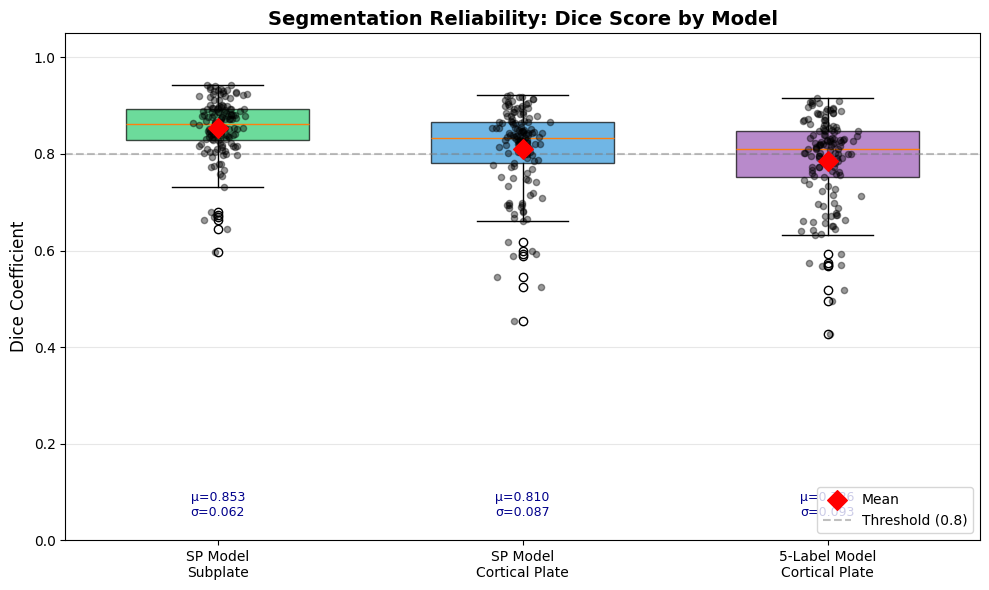

In [4]:
def plot_dice_by_model(df):
    """Box plot comparing Dice scores across models."""
    fig, ax = plt.subplots(figsize=(10, 6))

    models = [
        "SP Model - Subplate",
        "SP Model - Cortical Plate",
        "5-Label Model - Cortical Plate",
    ]
    model_labels = [
        "SP Model\nSubplate",
        "SP Model\nCortical Plate",
        "5-Label Model\nCortical Plate",
    ]
    colors = ["#2ecc71", "#3498db", "#9b59b6"]

    data = [df[df["model"] == m]["dice"].values for m in models]

    bp = ax.boxplot(data, tick_labels=model_labels, patch_artist=True, widths=0.6)

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, d in enumerate(data):
        x = np.random.normal(i + 1, 0.04, size=len(d))
        ax.scatter(x, d, alpha=0.4, s=20, color="black", zorder=3)

    means = [np.mean(d) for d in data]
    ax.scatter(
        range(1, len(models) + 1),
        means,
        color="red",
        s=100,
        zorder=5,
        marker="D",
        label="Mean",
    )

    ax.set_ylabel("Dice Coefficient", fontsize=12)
    ax.set_title(
        "Segmentation Reliability: Dice Score by Model", fontsize=14, fontweight="bold"
    )
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="Threshold (0.8)")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3, axis="y")

    for i, (m, d) in enumerate(zip(means, data)):
        ax.annotate(
            f"μ={m:.3f}\nσ={np.std(d):.3f}",
            xy=(i + 1, 0.05),
            ha="center",
            fontsize=9,
            color="darkblue",
        )

    plt.tight_layout()
    return fig


fig = plot_dice_by_model(reliability_df)
plt.show()

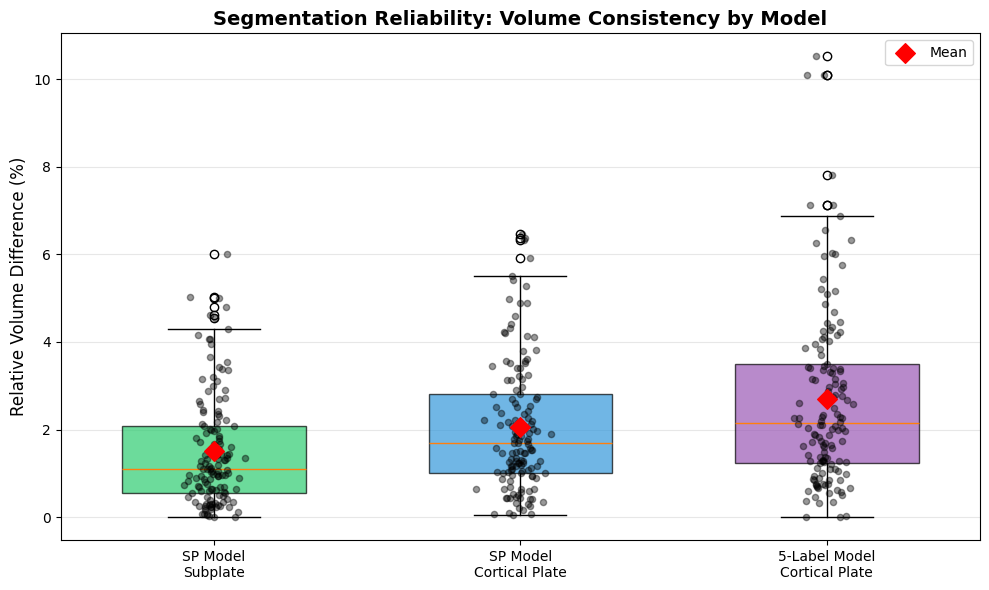

In [5]:
def plot_relative_diff_by_model(df):
    """Box plot comparing relative volume difference across models."""
    fig, ax = plt.subplots(figsize=(10, 6))

    models = ['SP Model - Subplate', 'SP Model - Cortical Plate', '5-Label Model - Cortical Plate']
    model_labels = ['SP Model\nSubplate', 'SP Model\nCortical Plate', '5-Label Model\nCortical Plate']
    colors = ['#2ecc71', '#3498db', '#9b59b6']

    data = [df[df['model'] == m]['relative_diff'].values for m in models]

    bp = ax.boxplot(data, tick_labels=model_labels, patch_artist=True, widths=0.6)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, d in enumerate(data):
        x = np.random.normal(i + 1, 0.04, size=len(d))
        ax.scatter(x, d, alpha=0.4, s=20, color='black', zorder=3)

    means = [np.mean(d) for d in data]
    ax.scatter(range(1, len(models) + 1), means, color='red', s=100, zorder=5, marker='D', label='Mean')

    ax.set_ylabel('Relative Volume Difference (%)', fontsize=12)
    ax.set_title('Segmentation Reliability: Volume Consistency by Model', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig

fig = plot_relative_diff_by_model(reliability_df)
plt.show()

/tmp/ipykernel_1028598/4106624776.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  subject_cmap = plt.cm.get_cmap('tab20', n_subjects)


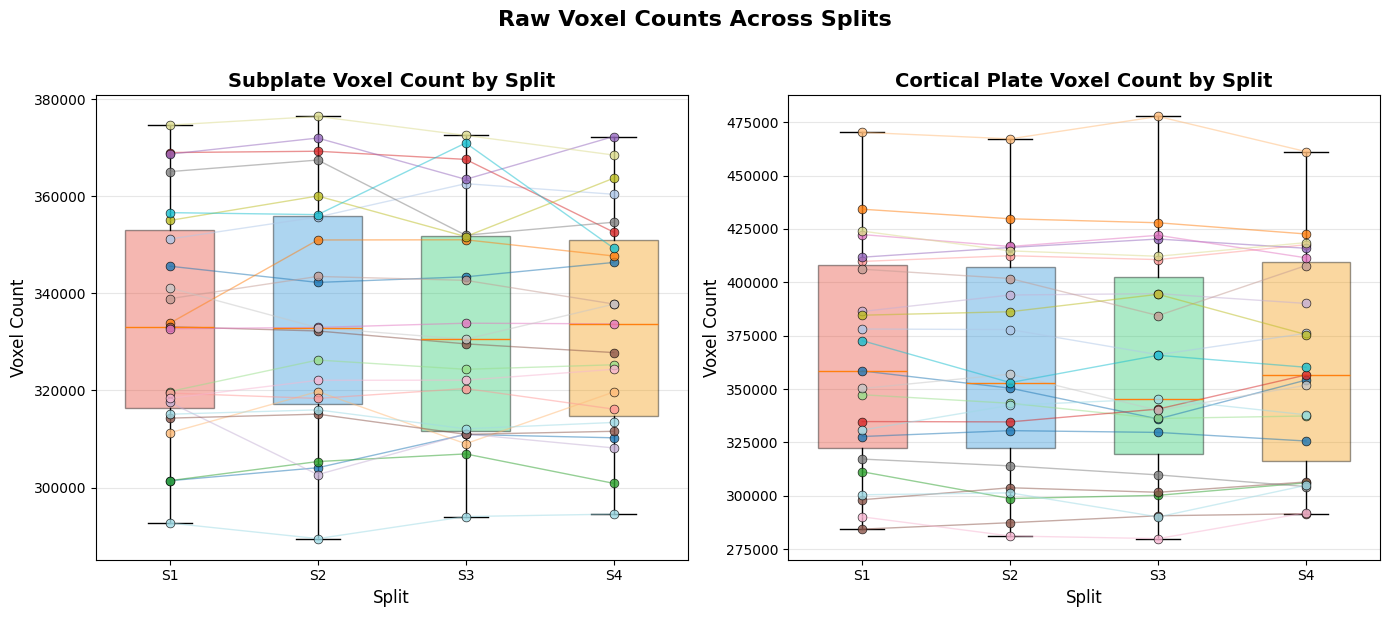

In [6]:
def plot_voxel_counts_by_split(quality_df):
    """
    Box plot showing raw voxel counts per split for each tissue type.
    This shows the absolute volume, not the relative difference.
    Each subject is color-coded and connected across splits.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    splits = ['S1', 'S2', 'S3', 'S4']
    box_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    
    # Generate a color for each subject
    n_subjects = len(quality_df)
    subject_cmap = plt.cm.get_cmap('tab20', n_subjects)
    subject_colors = {subj: subject_cmap(i) for i, subj in enumerate(quality_df['subject_id'].values)}

    # --- Subplate voxel counts ---
    ax = axes[0]
    sp_data = []
    for split in splits:
        col = f'voxels_sp_{split}'
        if col in quality_df.columns:
            sp_data.append(quality_df[col].dropna().values)
        else:
            sp_data.append([])

    bp = ax.boxplot(sp_data, tick_labels=splits, patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)

    # Plot each subject's points with unique color and connect them
    for idx, row in quality_df.iterrows():
        subj_id = row['subject_id']
        color = subject_colors[subj_id]
        
        x_positions = []
        y_values = []
        
        for i, split in enumerate(splits):
            col = f'voxels_sp_{split}'
            if col in quality_df.columns and pd.notna(row[col]):
                x_positions.append(i + 1)
                y_values.append(row[col])
        
        if len(x_positions) > 0:
            # Plot points
            ax.scatter(x_positions, y_values, color=color, s=40, alpha=0.8, 
                       edgecolors='black', linewidths=0.5, zorder=3)
            # Connect with lines
            ax.plot(x_positions, y_values, color=color, alpha=0.5, linewidth=1, zorder=2)

    ax.set_ylabel('Voxel Count', fontsize=12)
    ax.set_xlabel('Split', fontsize=12)
    ax.set_title('Subplate Voxel Count by Split', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # --- Cortical Plate voxel counts ---
    ax = axes[1]
    cp_data = []
    for split in splits:
        col = f'voxels_cp_{split}'
        if col in quality_df.columns:
            cp_data.append(quality_df[col].dropna().values)
        else:
            cp_data.append([])

    bp = ax.boxplot(cp_data, tick_labels=splits, patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)

    # Plot each subject's points with unique color and connect them
    for idx, row in quality_df.iterrows():
        subj_id = row['subject_id']
        color = subject_colors[subj_id]
        
        x_positions = []
        y_values = []
        
        for i, split in enumerate(splits):
            col = f'voxels_cp_{split}'
            if col in quality_df.columns and pd.notna(row[col]):
                x_positions.append(i + 1)
                y_values.append(row[col])
        
        if len(x_positions) > 0:
            # Plot points
            ax.scatter(x_positions, y_values, color=color, s=40, alpha=0.8, 
                       edgecolors='black', linewidths=0.5, zorder=3)
            # Connect with lines
            ax.plot(x_positions, y_values, color=color, alpha=0.5, linewidth=1, zorder=2)

    ax.set_ylabel('Voxel Count', fontsize=12)
    ax.set_xlabel('Split', fontsize=12)
    ax.set_title('Cortical Plate Voxel Count by Split', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Raw Voxel Counts Across Splits', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig

fig = plot_voxel_counts_by_split(quality_df)
plt.show()

/tmp/ipykernel_1028598/191017845.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  subject_cmap = plt.cm.get_cmap("tab20", n_subjects)


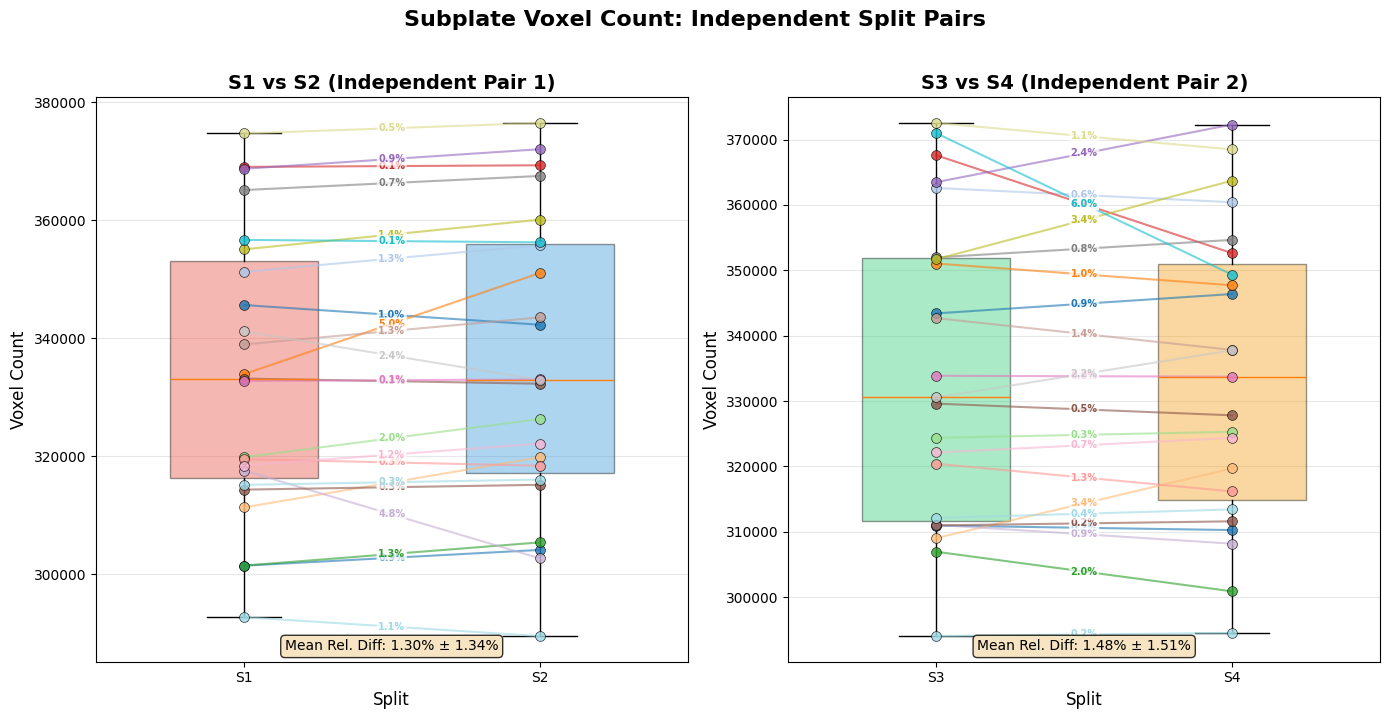

In [8]:
# === CELL 5b: Subplate Voxel Count - Independent Split Pairs ===


def plot_subplate_split_pairs(quality_df):
    """
    Side-by-side box plots showing subplate voxel counts for independent split pairs.
    S1-S2 and S3-S4 are independent pairs (no shared slices).
    Each subject is color-coded and connected within each pair.
    Percentage difference is displayed on each line.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Generate a color for each subject
    n_subjects = len(quality_df)
    subject_cmap = plt.cm.get_cmap("tab20", n_subjects)
    subject_colors = {
        subj: subject_cmap(i) for i, subj in enumerate(quality_df["subject_id"].values)
    }

    # --- S1 vs S2 (Independent Pair 1) ---
    ax = axes[0]
    splits_12 = ["S1", "S2"]
    box_colors_12 = ["#e74c3c", "#3498db"]

    sp_data_12 = []
    for split in splits_12:
        col = f"voxels_sp_{split}"
        if col in quality_df.columns:
            sp_data_12.append(quality_df[col].dropna().values)
        else:
            sp_data_12.append([])

    bp = ax.boxplot(sp_data_12, tick_labels=splits_12, patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], box_colors_12):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)

    # Plot each subject's points and connect S1 to S2
    for idx, row in quality_df.iterrows():
        subj_id = row["subject_id"]
        color = subject_colors[subj_id]

        s1_val = row.get("voxels_sp_S1", np.nan)
        s2_val = row.get("voxels_sp_S2", np.nan)

        if pd.notna(s1_val) and pd.notna(s2_val):
            ax.scatter(
                [1, 2],
                [s1_val, s2_val],
                color=color,
                s=50,
                alpha=0.8,
                edgecolors="black",
                linewidths=0.5,
                zorder=3,
            )
            ax.plot(
                [1, 2],
                [s1_val, s2_val],
                color=color,
                alpha=0.6,
                linewidth=1.5,
                zorder=2,
            )

            # Calculate relative difference
            mean_val = (s1_val + s2_val) / 2
            rel_diff = abs(s1_val - s2_val) / mean_val * 100

            # Position label at midpoint of line
            mid_y = (s1_val + s2_val) / 2
            ax.text(
                1.5,
                mid_y,
                f"{rel_diff:.1f}%",
                fontsize=7,
                ha="center",
                va="center",
                color=color,
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    facecolor="white",
                    alpha=0.7,
                    edgecolor="none",
                ),
            )

    ax.set_ylabel("Voxel Count", fontsize=12)
    ax.set_xlabel("Split", fontsize=12)
    ax.set_title("S1 vs S2 (Independent Pair 1)", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

    # Calculate and display mean relative difference
    if "voxels_sp_reldiff_S1S2" in quality_df.columns:
        mean_reldiff = quality_df["voxels_sp_reldiff_S1S2"].mean()
        std_reldiff = quality_df["voxels_sp_reldiff_S1S2"].std()
        ax.text(
            0.5,
            0.02,
            f"Mean Rel. Diff: {mean_reldiff:.2f}% ± {std_reldiff:.2f}%",
            transform=ax.transAxes,
            ha="center",
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )

    # --- S3 vs S4 (Independent Pair 2) ---
    ax = axes[1]
    splits_34 = ["S3", "S4"]
    box_colors_34 = ["#2ecc71", "#f39c12"]

    sp_data_34 = []
    for split in splits_34:
        col = f"voxels_sp_{split}"
        if col in quality_df.columns:
            sp_data_34.append(quality_df[col].dropna().values)
        else:
            sp_data_34.append([])

    bp = ax.boxplot(sp_data_34, tick_labels=splits_34, patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], box_colors_34):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)

    # Plot each subject's points and connect S3 to S4
    for idx, row in quality_df.iterrows():
        subj_id = row["subject_id"]
        color = subject_colors[subj_id]

        s3_val = row.get("voxels_sp_S3", np.nan)
        s4_val = row.get("voxels_sp_S4", np.nan)

        if pd.notna(s3_val) and pd.notna(s4_val):
            ax.scatter(
                [1, 2],
                [s3_val, s4_val],
                color=color,
                s=50,
                alpha=0.8,
                edgecolors="black",
                linewidths=0.5,
                zorder=3,
            )
            ax.plot(
                [1, 2],
                [s3_val, s4_val],
                color=color,
                alpha=0.6,
                linewidth=1.5,
                zorder=2,
            )

            # Calculate relative difference
            mean_val = (s3_val + s4_val) / 2
            rel_diff = abs(s3_val - s4_val) / mean_val * 100

            # Position label at midpoint of line
            mid_y = (s3_val + s4_val) / 2
            ax.text(
                1.5,
                mid_y,
                f"{rel_diff:.1f}%",
                fontsize=7,
                ha="center",
                va="center",
                color=color,
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    facecolor="white",
                    alpha=0.7,
                    edgecolor="none",
                ),
            )

    ax.set_ylabel("Voxel Count", fontsize=12)
    ax.set_xlabel("Split", fontsize=12)
    ax.set_title("S3 vs S4 (Independent Pair 2)", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

    # Calculate and display mean relative difference
    if "voxels_sp_reldiff_S3S4" in quality_df.columns:
        mean_reldiff = quality_df["voxels_sp_reldiff_S3S4"].mean()
        std_reldiff = quality_df["voxels_sp_reldiff_S3S4"].std()
        ax.text(
            0.5,
            0.02,
            f"Mean Rel. Diff: {mean_reldiff:.2f}% ± {std_reldiff:.2f}%",
            transform=ax.transAxes,
            ha="center",
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )

    plt.suptitle(
        "Subplate Voxel Count: Independent Split Pairs",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    return fig


fig = plot_subplate_split_pairs(quality_df)
plt.show()

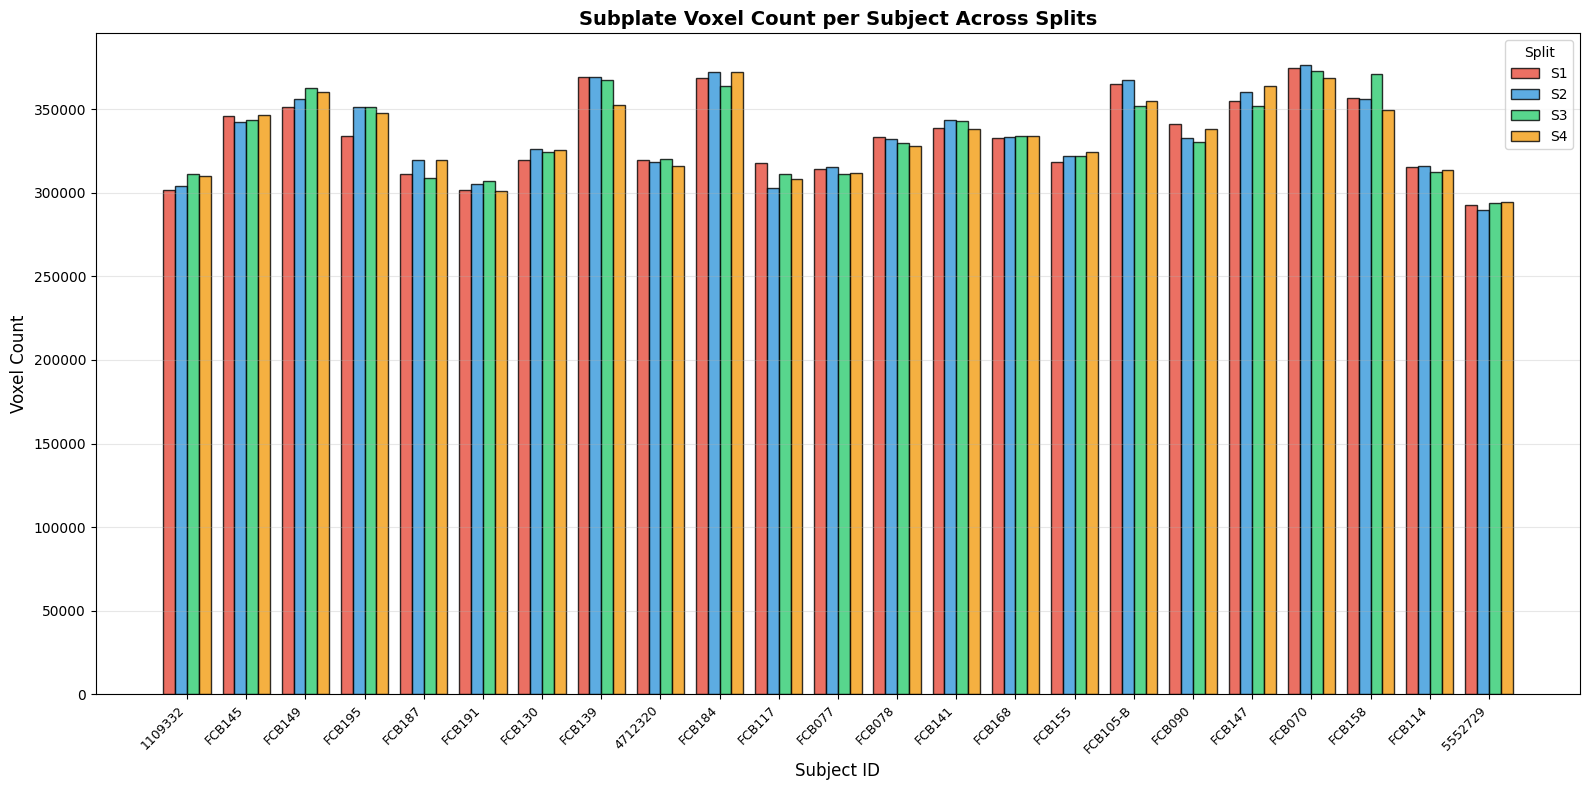

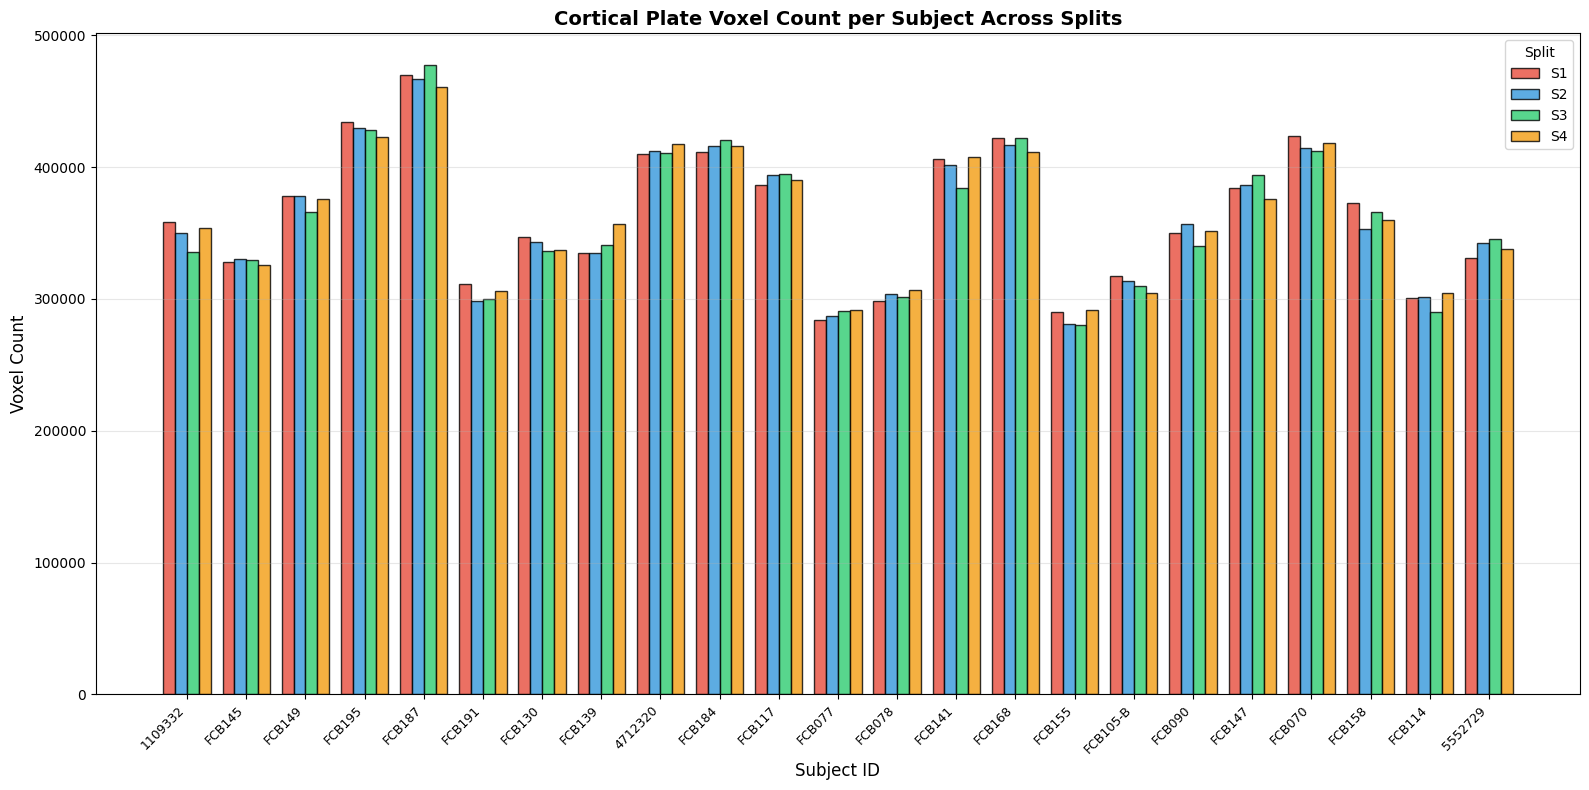

In [9]:
def plot_per_subject_voxel_counts(quality_df, tissue="sp"):
    """
    Bar plot showing voxel counts per subject for all 4 splits.
    Allows visual comparison of volume consistency within each subject.

    Parameters:
    -----------
    quality_df : pd.DataFrame
    tissue : str
        'sp' for subplate, 'cp' for cortical plate
    """
    tissue_name = "Subplate" if tissue == "sp" else "Cortical Plate"

    # Get subjects sorted by mean voxel count
    subjects = quality_df["subject_id"].astype(str).values

    splits = ["S1", "S2", "S3", "S4"]
    colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

    fig, ax = plt.subplots(figsize=(16, 8))

    x = np.arange(len(subjects))
    width = 0.2

    for i, (split, color) in enumerate(zip(splits, colors)):
        col = f"voxels_{tissue}_{split}"
        if col in quality_df.columns:
            values = quality_df[col].values
            offset = (i - 1.5) * width
            ax.bar(
                x + offset,
                values,
                width,
                label=split,
                color=color,
                alpha=0.8,
                edgecolor="black",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(subjects, rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Subject ID", fontsize=12)
    ax.set_ylabel("Voxel Count", fontsize=12)
    ax.set_title(
        f"{tissue_name} Voxel Count per Subject Across Splits",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend(title="Split", loc="upper right")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    return fig


# Plot for Subplate
fig = plot_per_subject_voxel_counts(quality_df, tissue="sp")
plt.show()

# Plot for Cortical Plate
fig = plot_per_subject_voxel_counts(quality_df, tissue="cp")
plt.show()

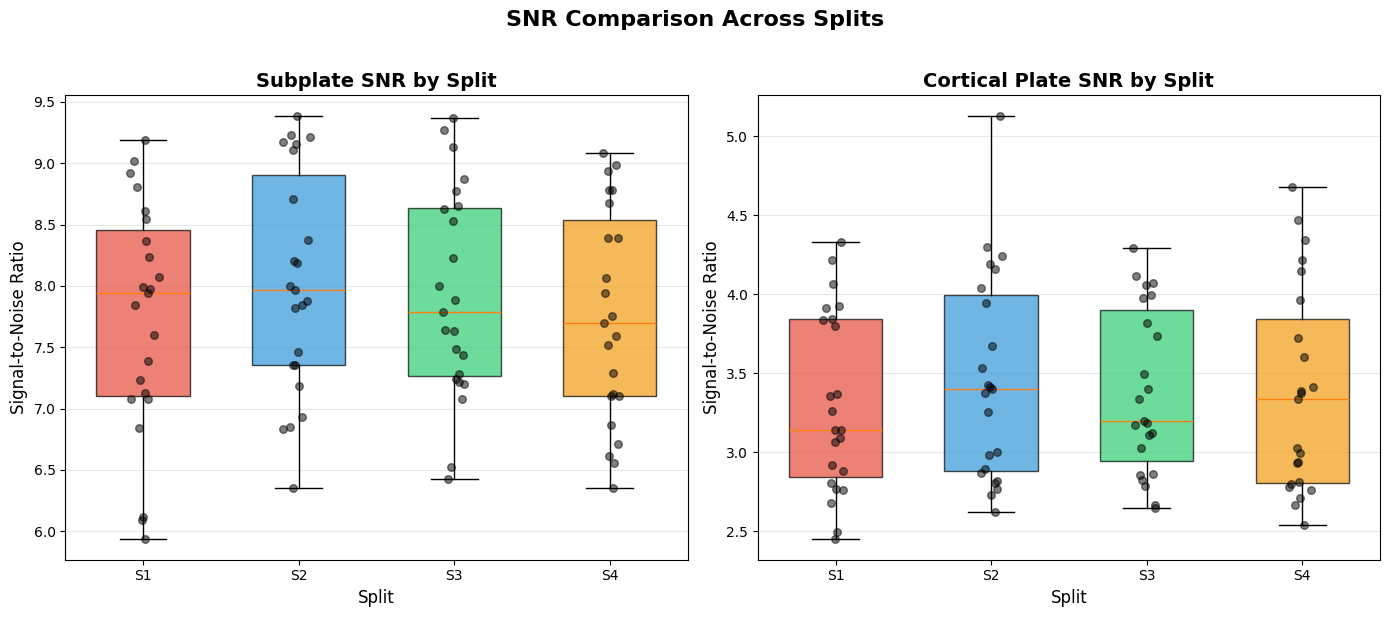

In [10]:
def plot_snr_by_split(quality_df):
    """
    Box plot showing SNR per split for each tissue type.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    splits = ['S1', 'S2', 'S3', 'S4']
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

    # Subplate SNR
    ax = axes[0]
    sp_data = []
    for split in splits:
        col = f'snr_sp_{split}'
        if col in quality_df.columns:
            sp_data.append(quality_df[col].dropna().values)
        else:
            sp_data.append([])

    if any(len(d) > 0 for d in sp_data):
        bp = ax.boxplot(sp_data, tick_labels=splits, patch_artist=True, widths=0.6)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        for i, d in enumerate(sp_data):
            if len(d) > 0:
                x = np.random.normal(i + 1, 0.04, size=len(d))
                ax.scatter(x, d, alpha=0.5, s=30, color='black', zorder=3)

    ax.set_ylabel('Signal-to-Noise Ratio', fontsize=12)
    ax.set_xlabel('Split', fontsize=12)
    ax.set_title('Subplate SNR by Split', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Cortical Plate SNR
    ax = axes[1]
    cp_data = []
    for split in splits:
        col = f'snr_cp_{split}'
        if col in quality_df.columns:
            cp_data.append(quality_df[col].dropna().values)
        else:
            cp_data.append([])

    if any(len(d) > 0 for d in cp_data):
        bp = ax.boxplot(cp_data, tick_labels=splits, patch_artist=True, widths=0.6)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        for i, d in enumerate(cp_data):
            if len(d) > 0:
                x = np.random.normal(i + 1, 0.04, size=len(d))
                ax.scatter(x, d, alpha=0.5, s=30, color='black', zorder=3)

    ax.set_ylabel('Signal-to-Noise Ratio', fontsize=12)
    ax.set_xlabel('Split', fontsize=12)
    ax.set_title('Cortical Plate SNR by Split', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('SNR Comparison Across Splits', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig

fig = plot_snr_by_split(quality_df)
plt.show()

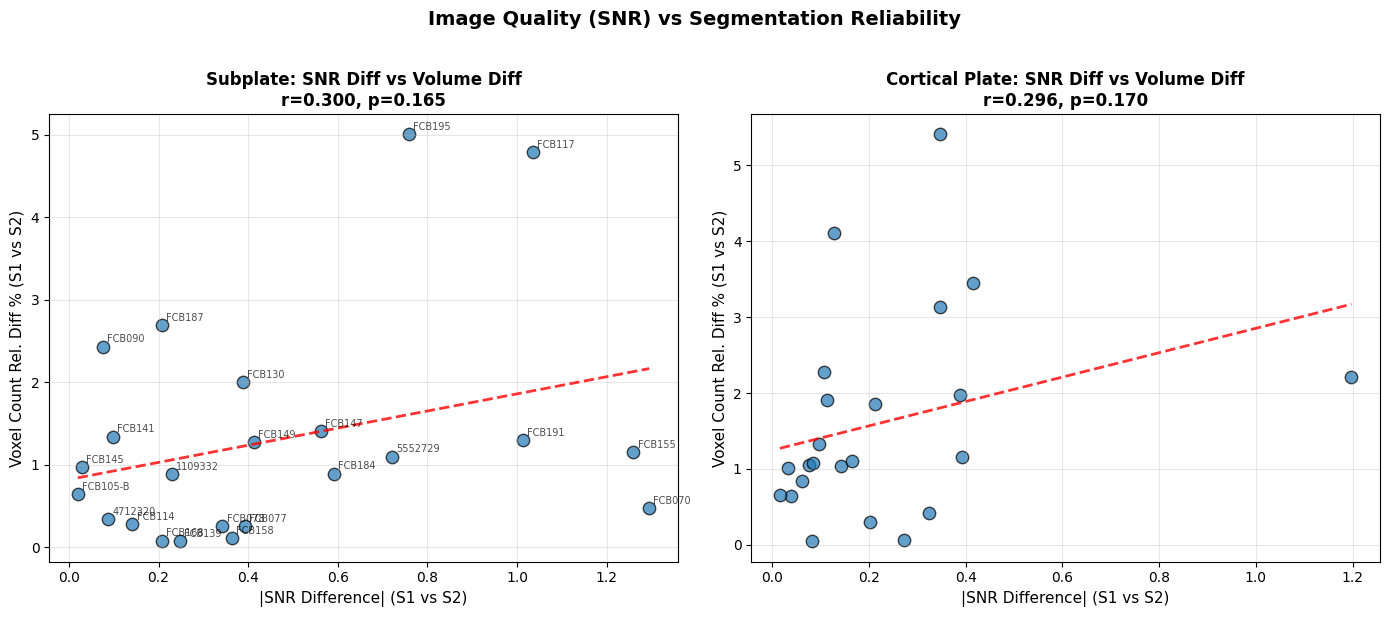

In [11]:
def plot_snr_reliability_correlation(quality_df, reliability_df):
    """
    Scatter plots showing correlation between SNR difference and reliability.
    Uses voxel count difference as the reliability metric (deterministic measure).
    """
    if len(quality_df) < 3:
        print(
            f"Need at least 3 subjects for correlation. Currently have {len(quality_df)}."
        )
        return None

    # For S1-S2 comparison (independent splits)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Check if we have the required columns
    snr_col = "snr_sp_diff_S1S2"
    vox_col = "voxels_sp_reldiff_S1S2"

    if snr_col not in quality_df.columns or vox_col not in quality_df.columns:
        print("Required columns not found. Run image_quality_metrics_v2.py first.")
        return None

    # Plot 1: SNR diff vs Voxel diff (Subplate)
    ax = axes[0]
    valid_mask = quality_df[snr_col].notna() & quality_df[vox_col].notna()
    x = quality_df.loc[valid_mask, snr_col]
    y = quality_df.loc[valid_mask, vox_col]

    if len(x) >= 3:
        ax.scatter(x, y, s=80, alpha=0.7, edgecolors="black")

        for idx in quality_df[valid_mask].index:
            ax.annotate(
                str(quality_df.loc[idx, "subject_id"])[:8],
                (quality_df.loc[idx, snr_col], quality_df.loc[idx, vox_col]),
                fontsize=7,
                alpha=0.7,
                xytext=(3, 3),
                textcoords="offset points",
            )

        r, p = stats.pearsonr(x, y)
        z = np.polyfit(x, y, 1)
        p_line = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p_line(x_line), "r--", alpha=0.8, linewidth=2)

        ax.set_xlabel("|SNR Difference| (S1 vs S2)", fontsize=11)
        ax.set_ylabel("Voxel Count Rel. Diff % (S1 vs S2)", fontsize=11)
        ax.set_title(
            f"Subplate: SNR Diff vs Volume Diff\nr={r:.3f}, p={p:.3f}",
            fontsize=12,
            fontweight="bold",
        )
        ax.grid(True, alpha=0.3)
    else:
        ax.text(
            0.5,
            0.5,
            "Insufficient data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

    # Plot 2: Same for Cortical Plate
    ax = axes[1]
    snr_col_cp = "snr_cp_diff_S1S2"
    vox_col_cp = "voxels_cp_reldiff_S1S2"

    if snr_col_cp in quality_df.columns and vox_col_cp in quality_df.columns:
        valid_mask = quality_df[snr_col_cp].notna() & quality_df[vox_col_cp].notna()
        x = quality_df.loc[valid_mask, snr_col_cp]
        y = quality_df.loc[valid_mask, vox_col_cp]

        if len(x) >= 3:
            ax.scatter(x, y, s=80, alpha=0.7, edgecolors="black")

            r, p = stats.pearsonr(x, y)
            z = np.polyfit(x, y, 1)
            p_line = np.poly1d(z)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, p_line(x_line), "r--", alpha=0.8, linewidth=2)

            ax.set_xlabel("|SNR Difference| (S1 vs S2)", fontsize=11)
            ax.set_ylabel("Voxel Count Rel. Diff % (S1 vs S2)", fontsize=11)
            ax.set_title(
                f"Cortical Plate: SNR Diff vs Volume Diff\nr={r:.3f}, p={p:.3f}",
                fontsize=12,
                fontweight="bold",
            )
            ax.grid(True, alpha=0.3)

    plt.suptitle(
        "Image Quality (SNR) vs Segmentation Reliability",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    return fig


fig = plot_snr_reliability_correlation(quality_df, reliability_df)
if fig:
    plt.show()

/tmp/ipykernel_1028598/1508504909.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


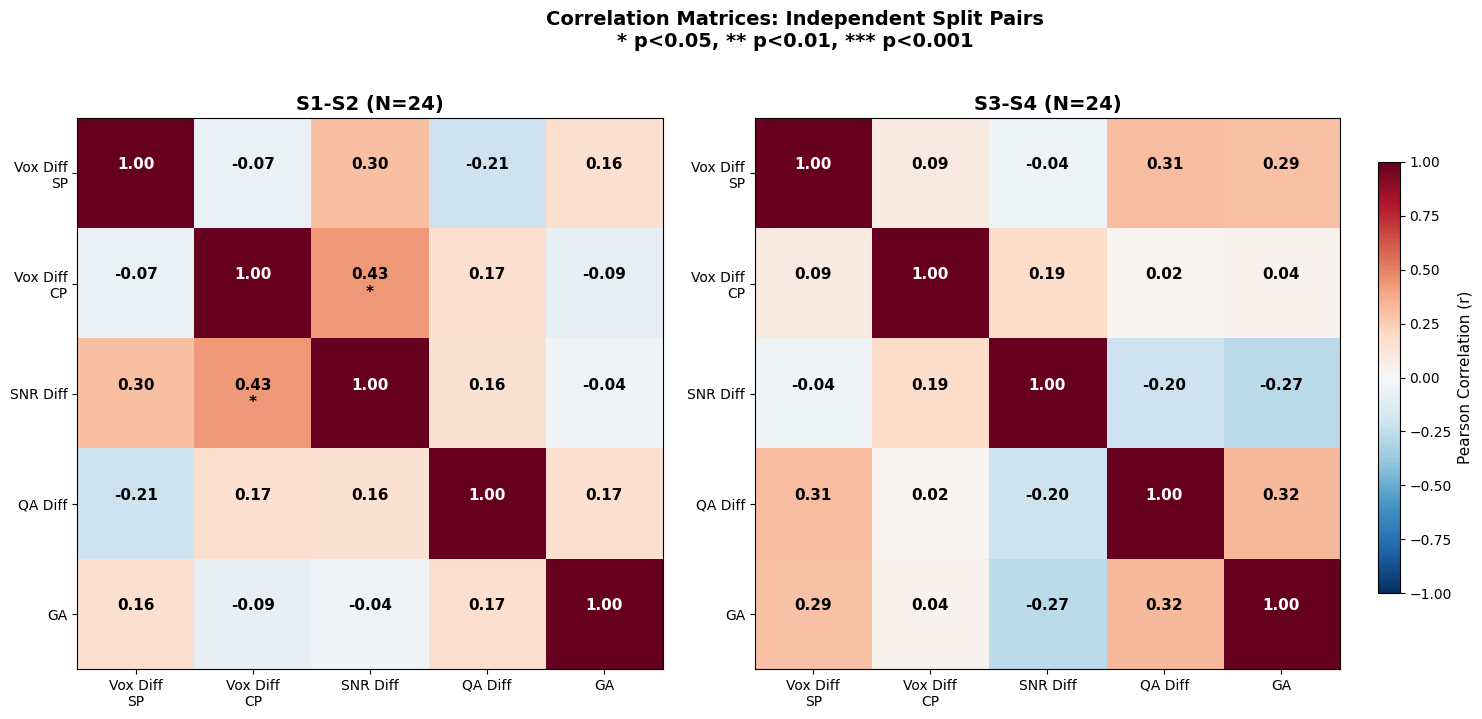

In [23]:
# === CELL 9: Correlation Matrix Heatmaps (S1-S2 and S3-S4) ===


def plot_correlation_matrices(quality_df, infodump_df):
    """
    Create two correlation matrix heatmaps - one for S1-S2 and one for S3-S4.
    Each shows relationships between:
    - Voxel count difference (SP and CP)
    - GA (Gestational Age)
    - QA difference
    - SNR difference
    """
    # Prepare merged dataframe
    merged = quality_df.copy()
    merged["subject_id"] = merged["subject_id"].astype(str)
    infodump_df = infodump_df.copy()
    infodump_df["subject_id"] = infodump_df["subject_id"].astype(str)

    # Calculate QA differences
    if "QA_S1" in infodump_df.columns and "QA_S2" in infodump_df.columns:
        infodump_df["qa_diff_S1S2"] = abs(infodump_df["QA_S1"] - infodump_df["QA_S2"])
    if "QA_S3" in infodump_df.columns and "QA_S4" in infodump_df.columns:
        infodump_df["qa_diff_S3S4"] = abs(infodump_df["QA_S3"] - infodump_df["QA_S4"])

    # Merge
    cols_to_merge = ["subject_id", "GA"]
    if "qa_diff_S1S2" in infodump_df.columns:
        cols_to_merge.append("qa_diff_S1S2")
    if "qa_diff_S3S4" in infodump_df.columns:
        cols_to_merge.append("qa_diff_S3S4")

    merged = merged.merge(
        infodump_df[cols_to_merge].drop_duplicates(), on="subject_id", how="left"
    )

    # Define column sets for each split pair
    split_configs = {
        "S1-S2": {
            "columns": [
                "voxels_sp_reldiff_S1S2",
                "voxels_cp_reldiff_S1S2",
                "snr_sp_diff_S1S2",
                "qa_diff_S1S2",
                "GA",
            ],
            "labels": ["Vox Diff\nSP", "Vox Diff\nCP", "SNR Diff", "QA Diff", "GA"],
        },
        "S3-S4": {
            "columns": [
                "voxels_sp_reldiff_S3S4",
                "voxels_cp_reldiff_S3S4",
                "snr_sp_diff_S3S4",
                "qa_diff_S3S4",
                "GA",
            ],
            "labels": ["Vox Diff\nSP", "Vox Diff\nCP", "SNR Diff", "QA Diff", "GA"],
        },
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax_idx, (split_name, config) in enumerate(split_configs.items()):
        ax = axes[ax_idx]

        # Filter to available columns
        available_cols = [col for col in config["columns"] if col in merged.columns]
        available_labels = [
            config["labels"][i]
            for i, col in enumerate(config["columns"])
            if col in merged.columns
        ]

        if len(available_cols) < 2:
            ax.text(
                0.5,
                0.5,
                f"Insufficient data for {split_name}",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_title(f"{split_name} Correlation Matrix")
            continue

        # Get complete cases
        corr_data = merged[available_cols].dropna()

        if len(corr_data) < 3:
            ax.text(
                0.5,
                0.5,
                f"Not enough complete cases\n(N={len(corr_data)})",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_title(f"{split_name} Correlation Matrix")
            continue

        # Compute correlation matrix
        corr_matrix = corr_data.corr(method="pearson")

        # Compute p-values
        n_vars = len(available_cols)
        p_matrix = np.zeros((n_vars, n_vars))
        for i in range(n_vars):
            for j in range(n_vars):
                if i == j:
                    p_matrix[i, j] = 0
                else:
                    _, p = stats.pearsonr(
                        corr_data[available_cols[i]], corr_data[available_cols[j]]
                    )
                    p_matrix[i, j] = p

        # Plot heatmap
        im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

        # Set ticks
        ax.set_xticks(range(len(available_labels)))
        ax.set_yticks(range(len(available_labels)))
        ax.set_xticklabels(available_labels, fontsize=10)
        ax.set_yticklabels(available_labels, fontsize=10)

        # Add correlation values and significance stars
        for i in range(n_vars):
            for j in range(n_vars):
                r = corr_matrix.iloc[i, j]
                p = p_matrix[i, j]

                # Significance stars
                if i != j:
                    if p < 0.001:
                        sig = "***"
                    elif p < 0.01:
                        sig = "**"
                    elif p < 0.05:
                        sig = "*"
                    else:
                        sig = ""
                else:
                    sig = ""

                # Text color based on correlation value
                text_color = "white" if abs(r) > 0.5 else "black"

                ax.text(
                    j,
                    i,
                    f"{r:.2f}\n{sig}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=11,
                    fontweight="bold",
                )

        ax.set_title(
            f"{split_name} (N={len(corr_data)})", fontsize=14, fontweight="bold"
        )

    # Add shared colorbar
    cbar = fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04, shrink=0.8)
    cbar.set_label("Pearson Correlation (r)", fontsize=11)

    plt.suptitle(
        "Correlation Matrices: Independent Split Pairs\n* p<0.05, ** p<0.01, *** p<0.001",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    return fig


fig = plot_correlation_matrices(quality_df, infodump_df)
plt.show()

In [24]:
def statistical_model_comparison(df):
    """Perform statistical tests comparing models."""
    print("\n" + "=" * 80)
    print("STATISTICAL COMPARISON BETWEEN MODELS")
    print("=" * 80)

    comparisons = [
        ("SP Model - Subplate", "SP Model - Cortical Plate"),
        ("SP Model - Subplate", "5-Label Model - Cortical Plate"),
        ("SP Model - Cortical Plate", "5-Label Model - Cortical Plate"),
    ]

    print("\nPairwise Wilcoxon signed-rank tests on Dice scores:")
    print("-" * 60)

    for model_a, model_b in comparisons:
        df_a = df[df["model"] == model_a].groupby("subject_id")["dice"].mean()
        df_b = df[df["model"] == model_b].groupby("subject_id")["dice"].mean()

        common_subjects = df_a.index.intersection(df_b.index)
        data_a = df_a.loc[common_subjects].values
        data_b = df_b.loc[common_subjects].values

        stat, p_value = stats.wilcoxon(data_a, data_b)
        mean_diff = np.mean(data_a) - np.mean(data_b)

        significance = (
            "***"
            if p_value < 0.001
            else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        )

        print(f"\n{model_a[:25]:25s} vs {model_b[:25]:25s}")
        print(f"  Mean difference: {mean_diff:+.4f}")
        print(f"  Wilcoxon p-value: {p_value:.4f} {significance}")
        print(f"  N subjects: {len(common_subjects)}")


statistical_model_comparison(reliability_df)


STATISTICAL COMPARISON BETWEEN MODELS

Pairwise Wilcoxon signed-rank tests on Dice scores:
------------------------------------------------------------

SP Model - Subplate       vs SP Model - Cortical Plate
  Mean difference: +0.0433
  Wilcoxon p-value: 0.0000 ***
  N subjects: 23

SP Model - Subplate       vs 5-Label Model - Cortical 
  Mean difference: +0.0669
  Wilcoxon p-value: 0.0000 ***
  N subjects: 23

SP Model - Cortical Plate vs 5-Label Model - Cortical 
  Mean difference: +0.0237
  Wilcoxon p-value: 0.0000 ***
  N subjects: 23


In [25]:
def print_final_summary(reliability_df, quality_df, infodump_df):
    """Print a final summary of key findings."""
    print("\n" + "=" * 80)
    print("FINAL SUMMARY REPORT")
    print("=" * 80)

    n_subjects = reliability_df["subject_id"].nunique()
    n_quality = len(quality_df)

    print(
        f"\nDataset: {n_subjects} subjects with reliability metrics, {n_quality} with quality metrics"
    )

    # GA range
    if "GA" in infodump_df.columns:
        ga_min = infodump_df["GA"].min()
        ga_max = infodump_df["GA"].max()
        print(f"Gestational Age range: {ga_min:.1f} - {ga_max:.1f} weeks")

    print("\n--- RELIABILITY RANKING (by mean Dice) ---")
    model_means = (
        reliability_df.groupby("model")["dice"].mean().sort_values(ascending=False)
    )
    for i, (model, mean_dice) in enumerate(model_means.items(), 1):
        std = reliability_df[reliability_df["model"] == model]["dice"].std()
        print(f"  {i}. {model}: {mean_dice:.4f} ± {std:.4f}")

    print("\n--- RELIABILITY RANKING (by mean Voxel Rel. Diff - lower is better) ---")
    model_vox = (
        reliability_df.groupby("model")["relative_diff"]
        .mean()
        .sort_values(ascending=True)
    )
    for i, (model, mean_vox) in enumerate(model_vox.items(), 1):
        std = reliability_df[reliability_df["model"] == model]["relative_diff"].std()
        print(f"  {i}. {model}: {mean_vox:.2f}% ± {std:.2f}%")

    # SNR summary
    if "snr_sp_mean" in quality_df.columns:
        print(f"\n--- SNR SUMMARY ---")
        print(
            f"  Mean SNR (Subplate): {quality_df['snr_sp_mean'].mean():.2f} ± {quality_df['snr_sp_mean'].std():.2f}"
        )
        print(
            f"  Mean SNR (Cortical Plate): {quality_df['snr_cp_mean'].mean():.2f} ± {quality_df['snr_cp_mean'].std():.2f}"
        )

    print("\n" + "=" * 80)


print_final_summary(reliability_df, quality_df, infodump_df)


FINAL SUMMARY REPORT

Dataset: 23 subjects with reliability metrics, 23 with quality metrics
Gestational Age range: 22.0 - 35.6 weeks

--- RELIABILITY RANKING (by mean Dice) ---
  1. SP Model - Subplate: 0.8533 ± 0.0621
  2. SP Model - Cortical Plate: 0.8101 ± 0.0869
  3. 5-Label Model - Cortical Plate: 0.7864 ± 0.0932

--- RELIABILITY RANKING (by mean Voxel Rel. Diff - lower is better) ---
  1. SP Model - Subplate: 1.50% ± 1.28%
  2. SP Model - Cortical Plate: 2.06% ± 1.49%
  3. 5-Label Model - Cortical Plate: 2.70% ± 2.07%

--- SNR SUMMARY ---
  Mean SNR (Subplate): 7.86 ± 0.85
  Mean SNR (Cortical Plate): 3.38 ± 0.58

